<a href="https://colab.research.google.com/github/kingsu52/rl-recommender-system/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# =========================================================
# ✅ COIL2000 보험 추천: DQN vs CQL 비교 실험 노트북 (주석 완전판)
# =========================================================

# -----------------------------
# 1. 라이브러리 임포트
# -----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -----------------------------
# 2. 데이터 로드 및 전처리
# -----------------------------
base_path = "./gdrive/MyDrive/Colab Notebooks/COIL2000/"

# COIL2000 평가용 feature
X = pd.read_csv(base_path + "ticeval2000.csv", header=None)

# COIL2000 평가용 target (보험 가입 여부)
y = pd.read_csv(base_path + "tictgts2000.csv", header=None)[0]

# DQN은 신경망 입력에 스케일링이 중요 → StandardScaler 적용
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3. 환경 정의 (Environment)
# -----------------------------
class InsuranceEvalEnv:
    """
    COIL2000 평가용 데이터를 한 줄씩 순차적으로 제공하는 환경.
    DQN/CQL 모두 동일한 환경에서 학습하도록 설계.
    """

    def __init__(self, X, y):
        self.X = X
        self.y = y.values if isinstance(y, pd.Series) else y
        self.n_samples = self.X.shape[0]
        self.n_features = self.X.shape[1]
        self.action_space = [0, 1]  # 0: 추천 안함, 1: 추천
        self.state_dim = self.n_features
        self.reset()

    def reset(self):
        """환경을 처음 상태로 초기화"""
        self.current_idx = 0
        return self.X[self.current_idx]

    def step(self, action):
        """
        action: 0 또는 1
        reward: 추천(1)했고 실제 가입(1)이면 reward=1, 아니면 0
        """
        state = self.X[self.current_idx]
        true_label = self.y[self.current_idx]

        # 추천(1) + 실제 가입(1)일 때만 reward=1
        reward = 1 if action == 1 and true_label == 1 else 0

        # 다음 상태로 이동
        self.current_idx += 1
        done = self.current_idx >= self.n_samples

        # 마지막이면 zero-state 반환
        next_state = self.X[self.current_idx] if not done else np.zeros(self.state_dim)

        return next_state, reward, done, {}

    def sample_action(self):
        """랜덤 행동 샘플링"""
        return random.choice(self.action_space)

# -----------------------------
# 4. Q-Network 및 Replay Buffer
# -----------------------------
class QNetwork(nn.Module):
    """
    상태 → 행동 가치(Q값)를 출력하는 신경망
    DQN과 CQL 모두 동일한 구조 사용
    """
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    """DQN/CQL 학습을 위한 경험 저장소"""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """transition 저장"""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """랜덤 샘플링"""
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

# GPU 사용 여부
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 5. DQN / CQL 공통 학습 함수
# -----------------------------
def train_agent(
    env,
    mode="dqn",              # "dqn" 또는 "cql"
    episodes=50,
    batch_size=64,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.1,
    epsilon_decay=0.995,
    alpha=1.0               # CQL conservative penalty weight
):
    """
    mode="dqn": 일반 DQN 학습
    mode="cql": Conservative Q-Learning 학습
    """

    state_dim = env.state_dim
    action_dim = len(env.action_space)

    # Q-network & target network
    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
    buffer = ReplayBuffer()
    epsilon = epsilon_start

    reward_log = []
    loss_log = []
    mse = nn.MSELoss()

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0

        while True:
            # ε-greedy 행동 선택
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            if random.random() < epsilon:
                action = random.choice(env.action_space)
            else:
                with torch.no_grad():
                    q_values = q_net(state_tensor)
                    action = q_values.argmax().item()

            # 환경 진행
            next_state, reward, done, _ = env.step(action)

            # transition 저장
            buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            # 일정 크기 이상이면 학습 시작
            if len(buffer) >= batch_size:
                s, a, r, s_, d = buffer.sample(batch_size)

                # numpy → tensor 변환
                s   = torch.FloatTensor(s).to(device)
                a   = torch.LongTensor(a).unsqueeze(1).to(device)
                r   = torch.FloatTensor(r).unsqueeze(1).to(device)
                s_  = torch.FloatTensor(s_).to(device)
                d   = torch.FloatTensor(d).unsqueeze(1).to(device)

                # Q(s,a)
                q_values = q_net(s).gather(1, a)

                # target = r + γ * max_a Q(s',a)
                with torch.no_grad():
                    next_q = target_net(s_).max(1)[0].unsqueeze(1)
                    target = r + gamma * next_q * (1 - d)

                # -----------------------------
                # ✅ DQN vs CQL 차이점 핵심
                # -----------------------------
                if mode == "dqn":
                    # 순수 DQN loss
                    loss = mse(q_values, target)

                elif mode == "cql":
                    # TD loss
                    td_loss = mse(q_values, target)

                    # Conservative penalty
                    q_all = q_net(s)  # (batch, 2)
                    logsumexp_q = torch.logsumexp(q_all, dim=1).mean()
                    q_logged = q_values.mean()

                    cql_penalty = logsumexp_q - q_logged

                    # 최종 CQL loss
                    loss = td_loss + alpha * cql_penalty

                else:
                    raise ValueError("mode must be 'dqn' or 'cql'")

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                loss_log.append(loss.item())

            if done:
                break

        # target network 업데이트
        if ep % 10 == 0:
            target_net.load_state_dict(q_net.state_dict())

        # ε 감소
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        reward_log.append(total_reward)
        print(f"[{mode.upper()}] Episode {ep+1}, Reward={total_reward}, Epsilon={epsilon:.3f}")

    return reward_log, loss_log

# -----------------------------
# 6. 환경 생성
# -----------------------------
env_dqn = InsuranceEvalEnv(X_scaled, y)
env_cql = InsuranceEvalEnv(X_scaled, y)

# -----------------------------
# 7. DQN 학습
# -----------------------------
print("\n===== Training DQN =====")
dqn_rewards, dqn_losses = train_agent(env_dqn, mode="dqn", episodes=50)

# -----------------------------
# 8. CQL 학습
# -----------------------------
print("\n===== Training CQL =====")
cql_rewards, cql_losses = train_agent(env_cql, mode="cql", episodes=50, alpha=1.0)

# -----------------------------
# 9. 결과 시각화
# -----------------------------

# ✅ 9-1. 에피소드 리워드 비교
plt.figure(figsize=(10,5))
plt.plot(dqn_rewards, label="DQN")
plt.plot(cql_rewards, label="CQL")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (DQN vs CQL)")
plt.legend()
plt.grid(True)
plt.show()

# ✅ 9-2. Loss 비교
plt.figure(figsize=(10,5))
plt.plot(dqn_losses, label="DQN Loss")
plt.plot(cql_losses, label="CQL Loss")
plt.xlabel("Update Step")
plt.ylabel("Loss")
plt.title("Training Loss (DQN vs CQL)")
plt.legend()
plt.grid(True)
plt.show()


Using device: cpu

===== Training DQN =====
[DQN] Episode 1, Reward=121, Epsilon=0.995
[DQN] Episode 2, Reward=108, Epsilon=0.990
[DQN] Episode 3, Reward=118, Epsilon=0.985
[DQN] Episode 4, Reward=120, Epsilon=0.980
[DQN] Episode 5, Reward=128, Epsilon=0.975
[DQN] Episode 6, Reward=137, Epsilon=0.970
[DQN] Episode 7, Reward=123, Epsilon=0.966
[DQN] Episode 8, Reward=116, Epsilon=0.961
[DQN] Episode 9, Reward=118, Epsilon=0.956
[DQN] Episode 10, Reward=130, Epsilon=0.951
[DQN] Episode 11, Reward=113, Epsilon=0.946
[DQN] Episode 12, Reward=128, Epsilon=0.942
[DQN] Episode 13, Reward=120, Epsilon=0.937
[DQN] Episode 14, Reward=134, Epsilon=0.932
[DQN] Episode 15, Reward=137, Epsilon=0.928
[DQN] Episode 16, Reward=123, Epsilon=0.923
[DQN] Episode 17, Reward=131, Epsilon=0.918
[DQN] Episode 18, Reward=139, Epsilon=0.914
[DQN] Episode 19, Reward=124, Epsilon=0.909
[DQN] Episode 20, Reward=132, Epsilon=0.905
[DQN] Episode 21, Reward=124, Epsilon=0.900
[DQN] Episode 22, Reward=122, Epsilon=0.8

In [7]:
import numpy as np
import matplotlib.pyplot as plt

alpha_list = [0.1, 0.5, 1.0, 2.0, 5.0]
alpha_results = {}

print("✅ 실험할 alpha 값:", alpha_list)

for alpha in alpha_list:
    print("\n====================================")
    print(f"✅ CQL 학습 시작 (alpha={alpha})")
    print("====================================")

    env_tmp = InsuranceEvalEnv(X_scaled, y)

    rewards, losses = train_agent(
        env_tmp,
        mode="cql",
        episodes=50,
        alpha=alpha
    )

    alpha_results[alpha] = {
        "rewards": rewards,
        "losses": losses
    }

print("\n✅ 모든 alpha 실험 완료!")

# ✅ 리워드 그래프
plt.figure(figsize=(12,6))
for alpha in alpha_list:
    plt.plot(alpha_results[alpha]["rewards"], label=f"alpha={alpha}")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("CQL Alpha Hyperparameter Comparison")
plt.legend()
plt.grid(True)
plt.show()

# ✅ 평균 리워드 막대 그래프
avg_rewards = [np.mean(alpha_results[a]["rewards"]) for a in alpha_list]
plt.figure(figsize=(10,5))
plt.bar([str(a) for a in alpha_list], avg_rewards)
plt.xlabel("Alpha")
plt.ylabel("Average Reward")
plt.title("Average Reward per Alpha (CQL)")
plt.grid(axis="y")
plt.show()

# ✅ 최적 alpha 선택
best_alpha = alpha_list[np.argmax(avg_rewards)]
best_score = np.max(avg_rewards)

print("\n====================================")
print("✅ CQL Alpha 실험 결과 요약")
print("====================================")
print("Alpha 값들:", alpha_list)
print("Alpha별 평균 리워드:", avg_rewards)
print("------------------------------------")
print(f"✅ 가장 좋은 alpha = {best_alpha}")
print(f"✅ 해당 alpha의 평균 리워드 = {best_score}")
print("====================================")


✅ 실험할 alpha 값: [0.1, 0.5, 1.0, 2.0, 5.0]

✅ CQL 학습 시작 (alpha=0.1)
[CQL] Episode 1, Reward=107, Action1=0.477, Eps=0.995
[CQL] Episode 2, Reward=124, Action1=0.508, Eps=0.990
[CQL] Episode 3, Reward=114, Action1=0.487, Eps=0.985
[CQL] Episode 4, Reward=112, Action1=0.509, Eps=0.980
[CQL] Episode 5, Reward=126, Action1=0.516, Eps=0.975
[CQL] Episode 6, Reward=115, Action1=0.498, Eps=0.970
[CQL] Episode 7, Reward=119, Action1=0.510, Eps=0.966
[CQL] Episode 8, Reward=123, Action1=0.503, Eps=0.961
[CQL] Episode 9, Reward=121, Action1=0.494, Eps=0.956
[CQL] Episode 10, Reward=114, Action1=0.507, Eps=0.951
[CQL] Episode 11, Reward=136, Action1=0.509, Eps=0.946
[CQL] Episode 12, Reward=122, Action1=0.504, Eps=0.942
[CQL] Episode 13, Reward=127, Action1=0.499, Eps=0.937
[CQL] Episode 14, Reward=130, Action1=0.509, Eps=0.932
[CQL] Episode 15, Reward=122, Action1=0.488, Eps=0.928
[CQL] Episode 16, Reward=130, Action1=0.500, Eps=0.923
[CQL] Episode 17, Reward=127, Action1=0.514, Eps=0.918
[CQL] Ep

ValueError: too many values to unpack (expected 2)

✅ 데이터 준비 완료: (4001, 85) (4001,)

===== Training DQN =====
[DQN] Episode 1, Reward=1, Action1=0.400, Eps=0.995
[DQN] Episode 2, Reward=0, Action1=0.350, Eps=0.990
[DQN] Episode 3, Reward=1, Action1=0.450, Eps=0.985
[DQN] Episode 4, Reward=0, Action1=0.400, Eps=0.980
[DQN] Episode 5, Reward=0, Action1=0.500, Eps=0.975
[DQN] Episode 6, Reward=2, Action1=0.800, Eps=0.970
[DQN] Episode 7, Reward=0, Action1=0.500, Eps=0.966
[DQN] Episode 8, Reward=0, Action1=0.500, Eps=0.961
[DQN] Episode 9, Reward=0, Action1=0.250, Eps=0.956
[DQN] Episode 10, Reward=0, Action1=0.450, Eps=0.951
[DQN] Episode 11, Reward=1, Action1=0.600, Eps=0.946
[DQN] Episode 12, Reward=0, Action1=0.600, Eps=0.942
[DQN] Episode 13, Reward=0, Action1=0.450, Eps=0.937
[DQN] Episode 14, Reward=1, Action1=0.550, Eps=0.932
[DQN] Episode 15, Reward=0, Action1=0.450, Eps=0.928
[DQN] Episode 16, Reward=0, Action1=0.450, Eps=0.923
[DQN] Episode 17, Reward=2, Action1=0.600, Eps=0.918
[DQN] Episode 18, Reward=1, Action1=0.500, Eps=0.9

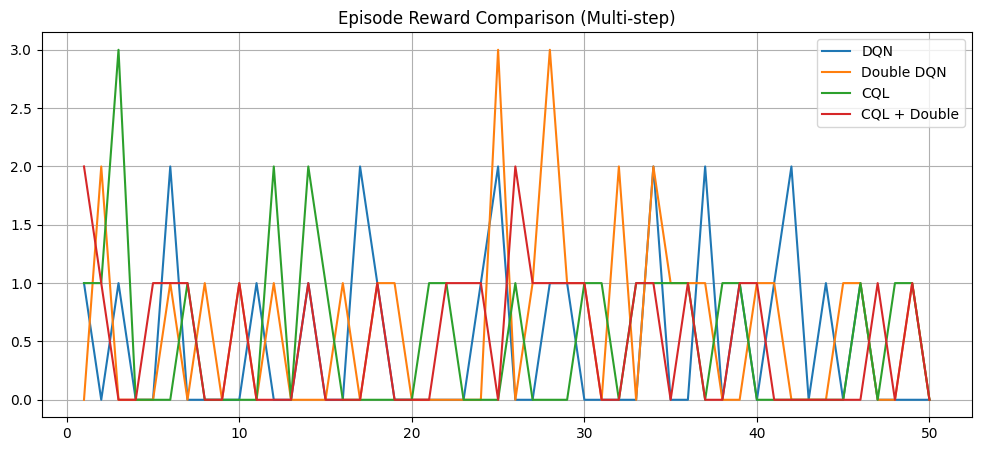

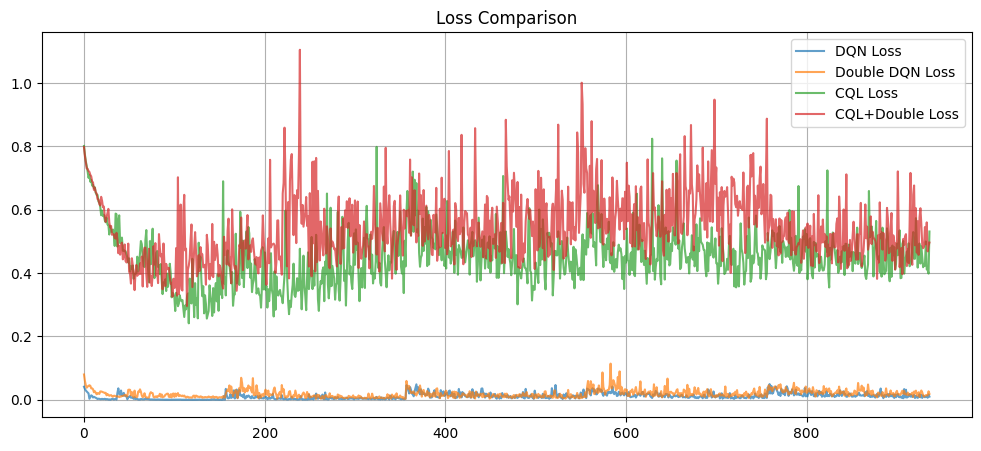

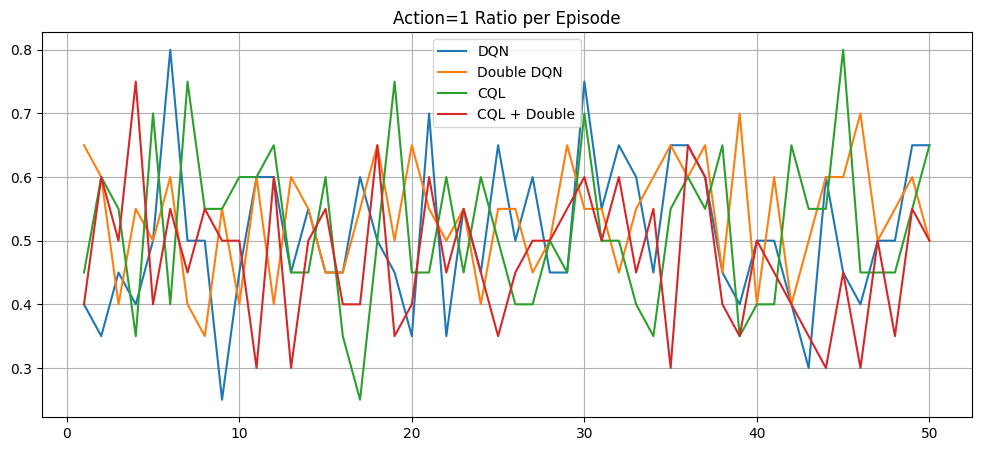

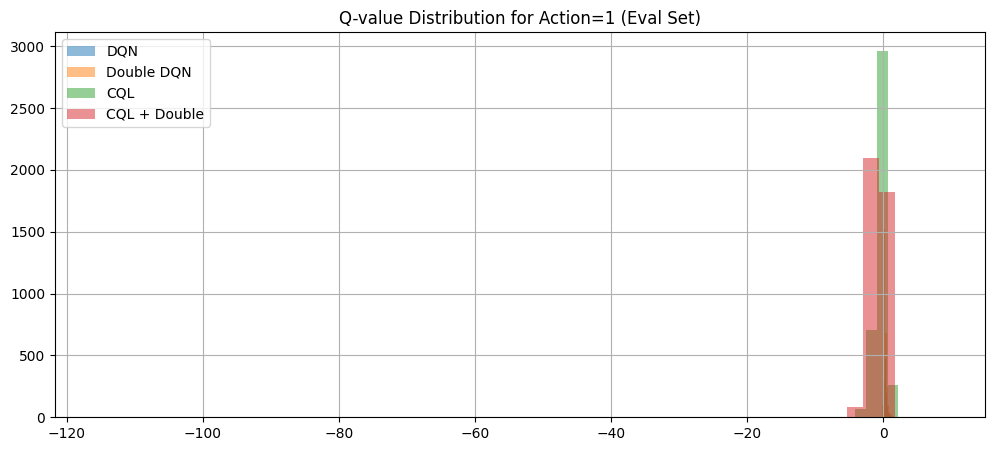

In [6]:
# =========================================================
# ✅ COIL2000 보험 추천: DQN / Double / CQL / CQL+Double
# ✅ 옵션 B: 멀티 스텝 환경 기반 완전 자동 실험 파일
# =========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# ✅ 1. COIL2000 데이터 로드 + 스케일링
# =========================================================
base_path = "./gdrive/MyDrive/Colab Notebooks/COIL2000/"

X = pd.read_csv(base_path + "ticeval2000.csv", header=None)
y = pd.read_csv(base_path + "tictgts2000.csv", header=None)[0]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ 데이터 준비 완료:", X_scaled.shape, y.shape)

# =========================================================
# ✅ 2. 멀티 스텝 환경 정의 (episode_len=20)
# =========================================================
class InsuranceSeqEnv:
    def __init__(self, X, y, episode_len=20):
        self.X = X
        self.y = y.values if isinstance(y, pd.Series) else y
        self.n = len(X)
        self.state_dim = X.shape[1]
        self.action_space = [0, 1]
        self.episode_len = episode_len

    def reset(self):
        self.indices = np.random.choice(self.n, self.episode_len, replace=False)
        self.ptr = 0
        return self.X[self.indices[self.ptr]]

    def step(self, action):
        idx = self.indices[self.ptr]
        reward = 1 if (action == 1 and self.y[idx] == 1) else 0

        self.ptr += 1
        done = (self.ptr >= self.episode_len)

        if not done:
            next_state = self.X[self.indices[self.ptr]]
        else:
            next_state = np.zeros(self.state_dim)

        return next_state, reward, done, {}

# =========================================================
# ✅ 3. Q-Network + ReplayBuffer
# =========================================================
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, s_, d):
        self.buffer.append((s, a, r, s_, d))
    def sample(self, batch):
        batch = random.sample(self.buffer, batch)
        s, a, r, s_, d = map(np.array, zip(*batch))
        return s, a, r, s_, d
    def __len__(self):
        return len(self.buffer)

# =========================================================
# ✅ 4. Double DQN Target
# =========================================================
def compute_double_dqn_target(q_net, target_net, s_, r, d, gamma):
    next_actions = q_net(s_).argmax(1).unsqueeze(1)
    next_q = target_net(s_).gather(1, next_actions)
    return r + gamma * next_q * (1 - d)

# =========================================================
# ✅ 5. 학습 함수 (DQN / Double / CQL / CQL+Double)
# =========================================================
def train_agent(env, mode="dqn", episodes=50, batch_size=64, gamma=0.99,
                epsilon_start=1.0, epsilon_end=0.1, epsilon_decay=0.995, alpha=1.0):

    state_dim = env.state_dim
    action_dim = len(env.action_space)

    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
    buffer = ReplayBuffer()
    epsilon = epsilon_start

    mse = nn.MSELoss()

    rewards, losses, action1_ratio = [], [], []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        total_steps = 0
        action1_count = 0

        while True:
            s_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

            if random.random() < epsilon:
                action = random.choice(env.action_space)
            else:
                with torch.no_grad():
                    action = q_net(s_tensor).argmax().item()

            next_state, reward, done, _ = env.step(action)
            buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            total_steps += 1
            if action == 1:
                action1_count += 1

            if len(buffer) >= batch_size:
                s, a, r, s_, d = buffer.sample(batch_size)

                s   = torch.FloatTensor(s).to(device)
                a   = torch.LongTensor(a).unsqueeze(1).to(device)
                r   = torch.FloatTensor(r).unsqueeze(1).to(device)
                s_  = torch.FloatTensor(s_).to(device)
                d   = torch.FloatTensor(d).unsqueeze(1).to(device)

                q_values = q_net(s).gather(1, a)

                if mode == "dqn":
                    next_q = target_net(s_).max(1)[0].unsqueeze(1)
                    target = r + gamma * next_q * (1 - d)

                elif mode == "double":
                    target = compute_double_dqn_target(q_net, target_net, s_, r, d, gamma)

                elif mode == "cql":
                    next_q = target_net(s_).max(1)[0].unsqueeze(1)
                    target = r + gamma * next_q * (1 - d)

                elif mode == "cql_double":
                    target = compute_double_dqn_target(q_net, target_net, s_, r, d, gamma)

                if mode in ["cql", "cql_double"]:
                    q_all = q_net(s)
                    logsumexp_q = torch.logsumexp(q_all, dim=1).mean()
                    q_logged = q_values.mean()
                    cql_penalty = logsumexp_q - q_logged
                    loss = mse(q_values, target) + alpha * cql_penalty
                else:
                    loss = mse(q_values, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                losses.append(loss.item())

            if done:
                break

        if ep % 10 == 0:
            target_net.load_state_dict(q_net.state_dict())

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)
        action1_ratio.append(action1_count / max(1, total_steps))

        print(f"[{mode.upper()}] Episode {ep+1}, Reward={total_reward}, "
              f"Action1={action1_ratio[-1]:.3f}, Eps={epsilon:.3f}")

    return {"q_net": q_net, "rewards": rewards, "losses": losses, "action1": action1_ratio}

# =========================================================
# ✅ 6. 4개 알고리즘 학습
# =========================================================
env_dqn = InsuranceSeqEnv(X_scaled, y)
env_double = InsuranceSeqEnv(X_scaled, y)
env_cql = InsuranceSeqEnv(X_scaled, y)
env_cql_double = InsuranceSeqEnv(X_scaled, y)

print("\n===== Training DQN =====")
res_dqn = train_agent(env_dqn, mode="dqn")

print("\n===== Training Double DQN =====")
res_double = train_agent(env_double, mode="double")

print("\n===== Training CQL =====")
res_cql = train_agent(env_cql, mode="cql", alpha=1.0)

print("\n===== Training CQL + Double DQN =====")
res_cql_double = train_agent(env_cql_double, mode="cql_double", alpha=1.0)

# =========================================================
# ✅ 7. 전체 데이터에서 Q값/행동 평가
# =========================================================
def eval_policy(q_net, X_eval):
    q_net.eval()
    with torch.no_grad():
        s = torch.FloatTensor(X_eval).to(device)
        q_all = q_net(s)
        actions = q_all.argmax(dim=1)
    return q_all.cpu().numpy(), actions.cpu().numpy()

q_dqn, a_dqn = eval_policy(res_dqn["q_net"], X_scaled)
q_double, a_double = eval_policy(res_double["q_net"], X_scaled)
q_cql, a_cql = eval_policy(res_cql["q_net"], X_scaled)
q_cql_double, a_cql_double = eval_policy(res_cql_double["q_net"], X_scaled)

# =========================================================
# ✅ 8. 시각화 (Reward / Loss / Action Ratio / Q값 분포)
# =========================================================
episodes = range(1, len(res_dqn["rewards"]) + 1)

# ✅ Reward 비교
plt.figure(figsize=(12,5))
plt.plot(episodes, res_dqn["rewards"], label="DQN")
plt.plot(episodes, res_double["rewards"], label="Double DQN")
plt.plot(episodes, res_cql["rewards"], label="CQL")
plt.plot(episodes, res_cql_double["rewards"], label="CQL + Double")
plt.title("Episode Reward Comparison (Multi-step)")
plt.legend(); plt.grid(); plt.show()

# ✅ Loss 비교
plt.figure(figsize=(12,5))
plt.plot(res_dqn["losses"], label="DQN Loss", alpha=0.7)
plt.plot(res_double["losses"], label="Double DQN Loss", alpha=0.7)
plt.plot(res_cql["losses"], label="CQL Loss", alpha=0.7)
plt.plot(res_cql_double["losses"], label="CQL+Double Loss", alpha=0.7)
plt.title("Loss Comparison")
plt.legend(); plt.grid(); plt.show()

# ✅ 추천 비율 비교
plt.figure(figsize=(12,5))
plt.plot(episodes, res_dqn["action1"], label="DQN")
plt.plot(episodes, res_double["action1"], label="Double DQN")
plt.plot(episodes, res_cql["action1"], label="CQL")
plt.plot(episodes, res_cql_double["action1"], label="CQL + Double")
plt.title("Action=1 Ratio per Episode")
plt.legend(); plt.grid(); plt.show()

# ✅ Q값 분포 비교
plt.figure(figsize=(12,5))
plt.hist(q_dqn[:,1], bins=50, alpha=0.5, label="DQN")
plt.hist(q_double[:,1], bins=50, alpha=0.5, label="Double DQN")
plt.hist(q_cql[:,1], bins=50, alpha=0.5, label="CQL")
plt.hist(q_cql_double[:,1], bins=50, alpha=0.5, label="CQL + Double")
plt.title("Q-value Distribution for Action=1 (Eval Set)")
plt.legend(); plt.grid(); plt.show()
